In [1]:
import torch
import pandas as pd
import numpy as np
import json
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

# Label info
label2id = {'authentic': 0, 'fake': 1, 'ai_fake': 2}
id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}
labels = ['authentic', 'fake', 'ai_fake']

C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\Riyad\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Device: cuda


In [2]:
# Load test data
test_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/test_final.csv')
test_df['text'] = test_df['headline'].fillna('') + ' ' + test_df['content'].fillna('')
test_df = test_df.dropna(subset=['text', 'label'])
test_df['label_id'] = test_df['label'].map(label2id)
test_df = test_df.dropna(subset=['label_id'])

print(f" Test data loaded: {len(test_df)}")

# Dataset class
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Evaluate function
def get_predictions(model, loader):
    model.eval()
    preds = []
    true_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred = outputs.logits.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            true_labels.extend(batch['label'].numpy())
    return preds, true_labels

print(" Functions ready!")

 Test data loaded: 2250
 Functions ready!


In [3]:
# Load BanglaBERT
print("Loading BanglaBERT...")
tokenizer_bb = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")
model_bb = AutoModelForSequenceClassification.from_pretrained(
    "csebuetnlp/banglabert",
    num_labels=3
)
model_bb.load_state_dict(torch.load(
    'C:/Users/Riyad/projects/fake_news/banglabert_best.pt',
    map_location=device
))
model_bb = model_bb.to(device)

# Dataloader
dataset_bb = NewsDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    tokenizer_bb
)
loader_bb = DataLoader(dataset_bb, batch_size=16)

# Get predictions
preds_bb, true_labels = get_predictions(model_bb, loader_bb)
print(f" BanglaBERT predictions done!")

# Free memory
del model_bb
torch.cuda.empty_cache()

Loading BanglaBERT...


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 BanglaBERT predictions done!


In [4]:
# Load XLM-RoBERTa
print("Loading XLM-RoBERTa...")
tokenizer_xlm = AutoTokenizer.from_pretrained("xlm-roberta-base")
model_xlm = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=3
)
model_xlm.load_state_dict(torch.load(
    'C:/Users/Riyad/projects/fake_news/xlmroberta_best.pt',
    map_location=device
))
model_xlm = model_xlm.to(device)

# Dataloader
dataset_xlm = NewsDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    tokenizer_xlm
)
loader_xlm = DataLoader(dataset_xlm, batch_size=8)

# Get predictions
preds_xlm, _ = get_predictions(model_xlm, loader_xlm)
print(f" XLM-RoBERTa predictions done!")

# Free memory
del model_xlm
torch.cuda.empty_cache()

Loading XLM-RoBERTa...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 XLM-RoBERTa predictions done!


In [5]:
# Load mBERT
print("Loading mBERT...")
tokenizer_mbert = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
model_mbert = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=3
)
model_mbert.load_state_dict(torch.load(
    'C:/Users/Riyad/projects/fake_news/mbert_best.pt',
    map_location=device
))
model_mbert = model_mbert.to(device)

# Dataloader
dataset_mbert = NewsDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    tokenizer_mbert
)
loader_mbert = DataLoader(dataset_mbert, batch_size=8)

# Get predictions
preds_mbert, _ = get_predictions(model_mbert, loader_mbert)
print(f" mBERT predictions done!")

# Free memory
del model_mbert
torch.cuda.empty_cache()

Loading mBERT...


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

 mBERT predictions done!


In [ ]:
from peft import PeftModel

# Load BLOOM
print("Loading BLOOM...")
from transformers import AutoModelForSequenceClassification

base_model = AutoModelForSequenceClassification.from_pretrained(
    "bigscience/bloom-560m",
    num_labels=3,
    torch_dtype=torch.float16
)
base_model.config.pad_token_id = base_model.config.eos_token_id

model_bloom = PeftModel.from_pretrained(
    base_model,
    'C:/Users/Riyad/projects/fake_news/bloom_lora_best'
)
model_bloom = model_bloom.to(device)

# Tokenizer
from transformers import AutoTokenizer
tokenizer_bloom = AutoTokenizer.from_pretrained("bigscience/bloom-560m")
tokenizer_bloom.pad_token = tokenizer_bloom.eos_token

# Dataloader
dataset_bloom = NewsDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    tokenizer_bloom
)
loader_bloom = DataLoader(dataset_bloom, batch_size=8)

# Get predictions
preds_bloom, _ = get_predictions(model_bloom, loader_bloom)
print(f" BLOOM predictions done!")

# Free memory
del model_bloom
torch.cuda.empty_cache()

Loading BLOOM...


Some weights of BloomForSequenceClassification were not initialized from the model checkpoint at bigscience/bloom-560m and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using `past_key_values` as a tuple is deprecated and will be removed in v4.45. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


✅ BLOOM predictions done!


In [7]:
import torch.nn as nn

# BiLSTM Model definition
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)

# Rebuild vocabulary
from collections import Counter

def tokenize(text):
    return text.split()

word_freq = Counter()
train_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/train_final.csv')
train_df['text'] = train_df['headline'].fillna('') + ' ' + train_df['content'].fillna('')
for text in train_df['text']:
    word_freq.update(tokenize(str(text)))

vocab_size = 30000
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in word_freq.most_common(vocab_size - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

# BiLSTM Dataset
class BiLSTMDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=256):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(str(self.texts[idx]))[:self.max_len]
        ids = [self.word2idx.get(t, 1) for t in tokens]
        if len(ids) < self.max_len:
            ids += [0] * (self.max_len - len(ids))
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Load BiLSTM model
print("Loading BiLSTM...")
model_bilstm = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    num_classes=3
).to(device)

model_bilstm.load_state_dict(torch.load(
    'C:/Users/Riyad/projects/fake_news/bilstm_best.pt',
    map_location=device
))

# Dataloader
dataset_bilstm = BiLSTMDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    word2idx
)
loader_bilstm = DataLoader(dataset_bilstm, batch_size=32)

# Get predictions
def get_bilstm_predictions(model, loader):
    model.eval()
    preds = []
    true_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            outputs = model(input_ids)
            pred = outputs.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            true_labels.extend(batch['label'].numpy())
    return preds, true_labels

preds_bilstm, _ = get_bilstm_predictions(model_bilstm, loader_bilstm)
print(" BiLSTM predictions done!")

# Free memory
del model_bilstm
torch.cuda.empty_cache()

Loading BiLSTM...
 BiLSTM predictions done!


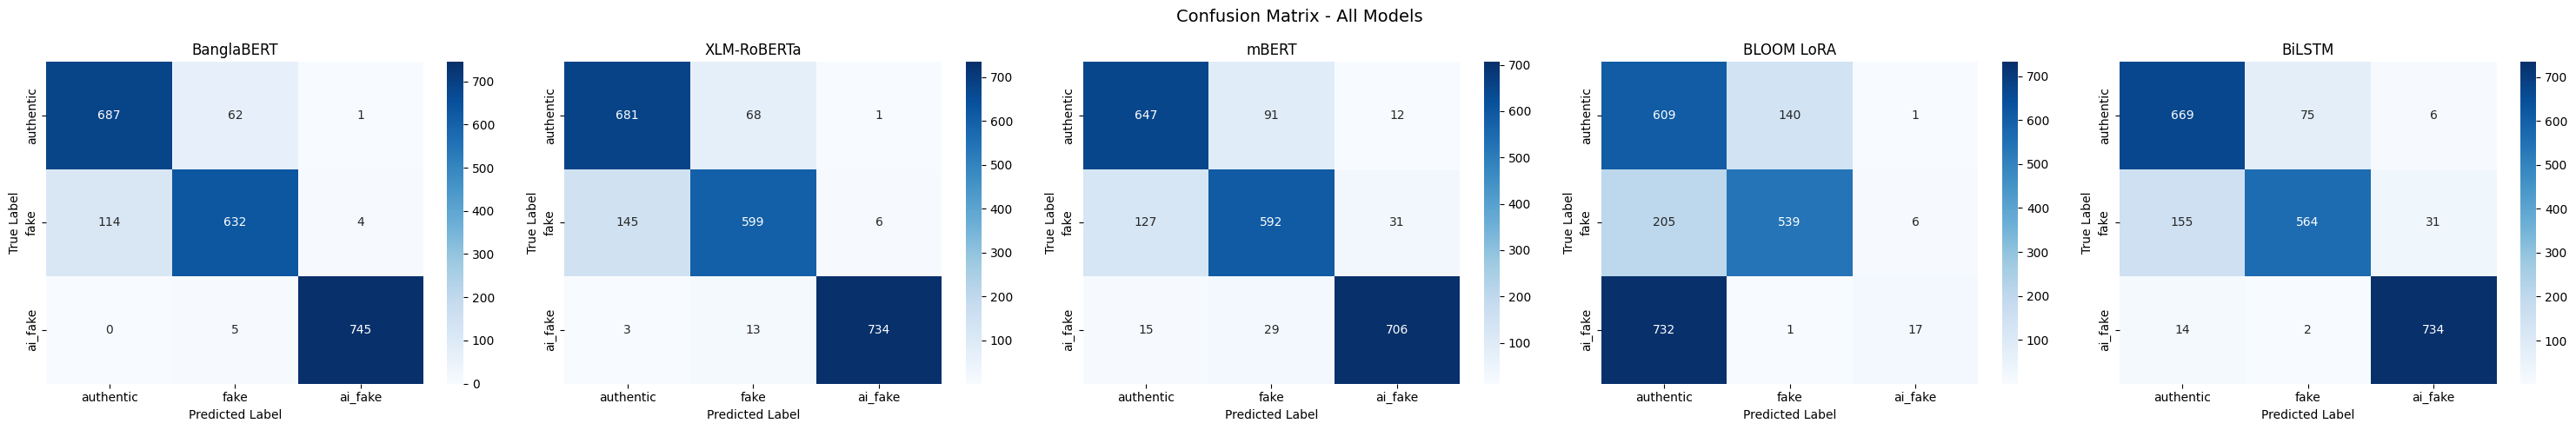

 Confusion Matrix saved!


In [8]:
# All model predictions
all_models = {
    'BanglaBERT': preds_bb,
    'XLM-RoBERTa': preds_xlm,
    'mBERT': preds_mbert,
    'BLOOM LoRA': preds_bloom,
    'BiLSTM': preds_bilstm
}

# Convert true labels to names
true_label_names = [id2label[t] for t in true_labels]
label_names = ['authentic', 'fake', 'ai_fake']

# Plot
fig, axes = plt.subplots(1, 5, figsize=(30, 5))

for idx, (name, preds) in enumerate(all_models.items()):
    pred_names = [id2label[p] for p in preds]
    
    cm = confusion_matrix(true_label_names, pred_names, labels=label_names)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrix - All Models', fontsize=14)
plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/confusion_matrix_all.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print(" Confusion Matrix saved!")

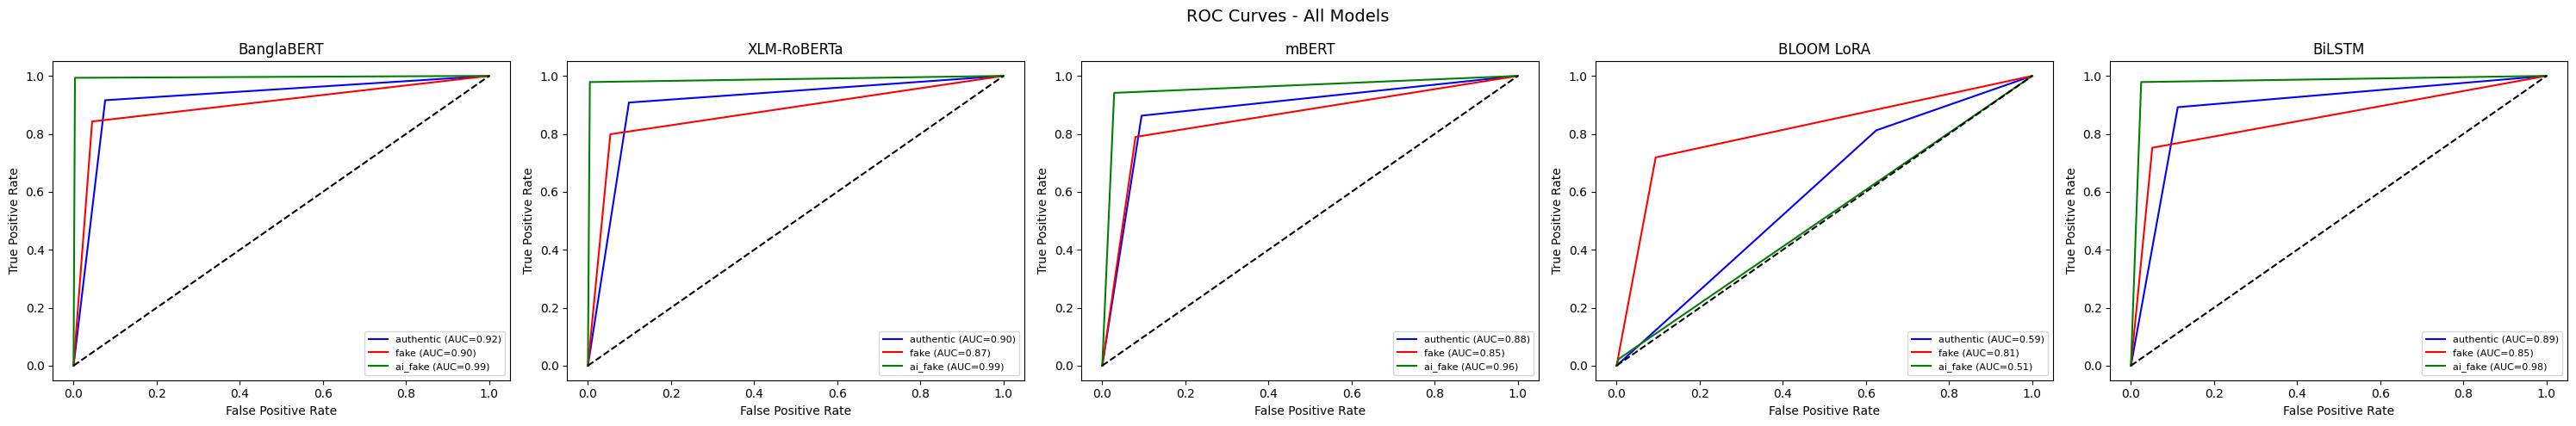

 ROC Curves saved!


In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = np.array([id2label[t] for t in true_labels])
y_true_bin = label_binarize(y_true, classes=['authentic', 'fake', 'ai_fake'])

# All model predictions
all_preds = {
    'BanglaBERT': preds_bb,
    'XLM-RoBERTa': preds_xlm,
    'mBERT': preds_mbert,
    'BLOOM LoRA': preds_bloom,
    'BiLSTM': preds_bilstm
}

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
class_names = ['authentic', 'fake', 'ai_fake']
colors = ['blue', 'red', 'green']

for idx, (name, preds) in enumerate(all_preds.items()):
    y_pred_bin = label_binarize(
        [id2label[p] for p in preds],
        classes=['authentic', 'fake', 'ai_fake']
    )
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=color, 
                      label=f'{cls} (AUC={roc_auc:.2f})')
    
    axes[idx].plot([0, 1], [0, 1], 'k--')
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].legend(loc='lower right', fontsize=8)

plt.suptitle('ROC Curves - All Models', fontsize=14)
plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/roc_curves.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print(" ROC Curves saved!")

In [10]:
import pickle
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load models
with open('C:/Users/Riyad/projects/fake_news/svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)

# Get predictions
test_texts = test_df['text'].fillna('').astype(str)

svm_preds = svm_model.predict(test_texts)

# NB + LR rebuild
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

train_df2 = pd.read_csv('C:/Users/Riyad/projects/fake_news/train_final.csv')
train_df2['text'] = train_df2['headline'].fillna('') + ' ' + train_df2['content'].fillna('')

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,3), max_features=50000, sublinear_tf=True)),
    ('clf', MultinomialNB())
])
nb_pipeline.fit(train_df2['text'], train_df2['label'])
nb_preds = nb_pipeline.predict(test_texts)

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,3), max_features=50000, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
lr_pipeline.fit(train_df2['text'], train_df2['label'])
lr_preds = lr_pipeline.predict(test_texts)

print(" SVM, NB, LR predictions done!")

 SVM, NB, LR predictions done!


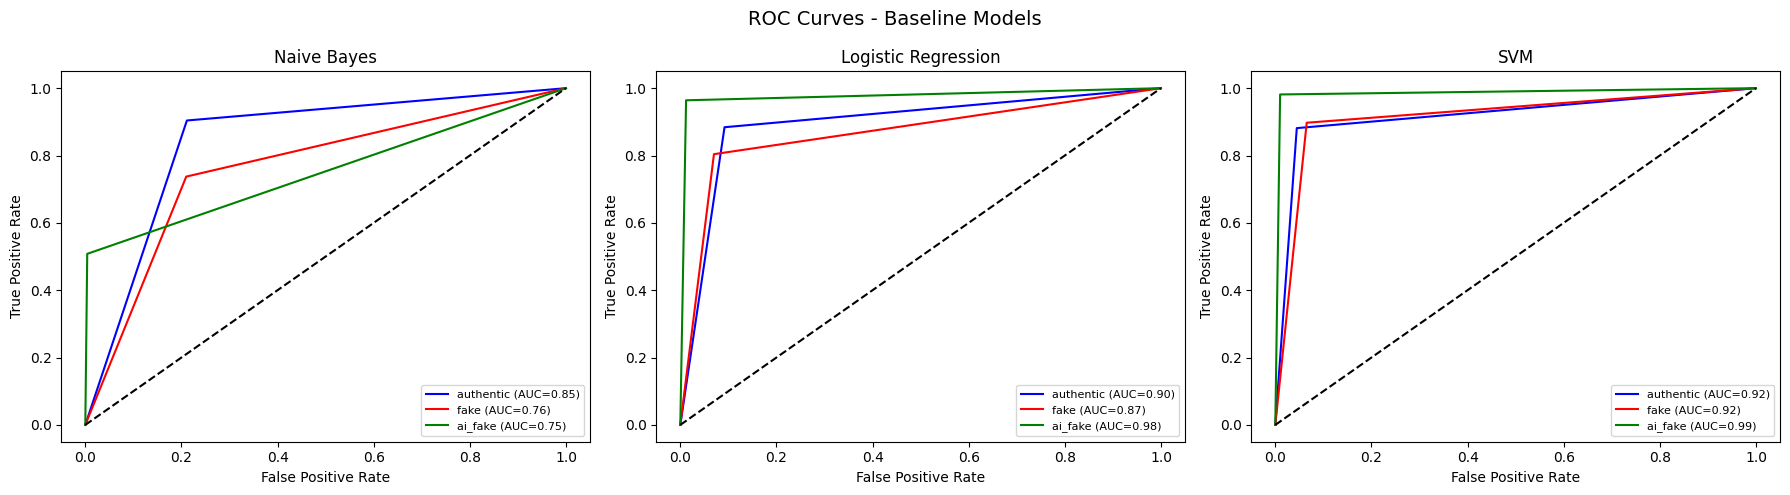

 Baseline ROC Curves saved!


In [12]:
# True labels
y_true_names = test_df['label'].values
y_true_bin = label_binarize(y_true_names, classes=['authentic', 'fake', 'ai_fake'])

# All baseline predictions
baseline_preds = {
    'Naive Bayes': nb_preds,
    'Logistic Regression': lr_preds,
    'SVM': svm_preds
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['authentic', 'fake', 'ai_fake']
colors = ['blue', 'red', 'green']

for idx, (name, preds) in enumerate(baseline_preds.items()):
    y_pred_bin = label_binarize(preds, classes=['authentic', 'fake', 'ai_fake'])
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=color,
                      label=f'{cls} (AUC={roc_auc:.2f})')
    
    axes[idx].plot([0, 1], [0, 1], 'k--')
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].legend(loc='lower right', fontsize=8)

plt.suptitle('ROC Curves - Baseline Models', fontsize=14)
plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/roc_curves_baseline.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print(" Baseline ROC Curves saved!")

In [5]:
import json

# Load Llama predictions from json file
with open('C:\\Users\\Riyad\\projects\\fake_news\\Lalama\\preds_llama.json', 'r') as f:
    llama_data = json.load(f)

preds_llama = llama_data['preds']
true_llama = llama_data['true']

print(f"Llama predictions loaded!")
print(f"Total: {len(preds_llama)}")

Llama predictions loaded!
Total: 2250


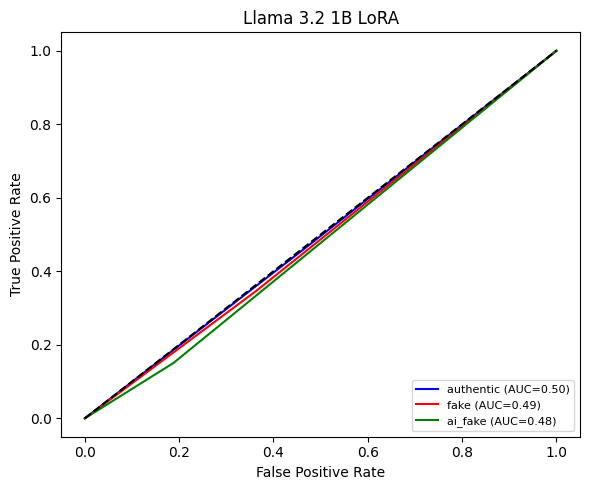

 Llama ROC Curve saved!


In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}
class_names = ['authentic', 'fake', 'ai_fake']
# Llama ROC Curve
y_true_bin_llama = label_binarize(
    [id2label[t] for t in true_llama],
    classes=['authentic', 'fake', 'ai_fake']
)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
colors = ['blue', 'red', 'green']

for i, (cls, color) in enumerate(zip(class_names, colors)):
    y_pred_bin = label_binarize(
        [id2label[p] for p in preds_llama],
        classes=['authentic', 'fake', 'ai_fake']
    )
    fpr, tpr, _ = roc_curve(y_true_bin_llama[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color,
            label=f'{cls} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_title('Llama 3.2 1B LoRA', fontsize=12)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/roc_curve_llama.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print(" Llama ROC Curve saved!")